# **Importing Libraries**

In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# **Mounting the Drive**

In [58]:
# from google.colab import drive
# drive.mount('/content/drive')

# **Checking Wheather the Dataset is Biased or Not**

## **Loading Dataset**

In [59]:
df = pd.read_csv('EVChargingStationUsage.csv')

/var/folders/kw/74qcbwv90c7_n8074285nr8m0000gn/T/ipykernel_37198/126744140.py:1: DtypeWarning: Columns (29,30,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('EVChargingStationUsage.csv')


## **Checking**

In [60]:
df.columns

Index(['Station Name', 'MAC Address', 'Org Name', 'Start Date',
       'Start Time Zone', 'End Date', 'End Time Zone',
       'Transaction Date (Pacific Time)', 'Total Duration (hh:mm:ss)',
       'Charging Time (hh:mm:ss)', 'Energy (kWh)', 'GHG Savings (kg)',
       'Gasoline Savings (gallons)', 'Port Type', 'Port Number', 'Plug Type',
       'EVSE ID', 'Address 1', 'City', 'State/Province', 'Postal Code',
       'Country', 'Latitude', 'Longitude', 'Currency', 'Fee', 'Ended By',
       'Plug In Event Id', 'Driver Postal Code', 'User ID', 'County',
       'System S/N', 'Model Number'],
      dtype='object')

In [61]:
df['Station Name'].nunique()
df['Station Name'].value_counts(normalize=True).head()

Station Name
PALO ALTO CA / HAMILTON #2    0.091440
PALO ALTO CA / HAMILTON #1    0.057391
PALO ALTO CA / WEBSTER #1     0.055633
PALO ALTO CA / BRYANT #2      0.055467
PALO ALTO CA / HIGH #4        0.053574
Name: proportion, dtype: float64

In [62]:
print("Unique Stations:", df['Station Name'].nunique())
df['Station Name'].value_counts().head(10)

Unique Stations: 47


Station Name
PALO ALTO CA / HAMILTON #2     23721
PALO ALTO CA / HAMILTON #1     14888
PALO ALTO CA / WEBSTER #1      14432
PALO ALTO CA / BRYANT #2       14389
PALO ALTO CA / HIGH #4         13898
PALO ALTO CA / BRYANT #1       13436
PALO ALTO CA / WEBSTER #2      12669
PALO ALTO CA / CAMBRIDGE #1    11163
PALO ALTO CA / HIGH #1         10756
PALO ALTO CA / WEBSTER #3      10484
Name: count, dtype: int64

In [63]:
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['Hour'] = df['Start Date'].dt.hour
df['Weekday'] = df['Start Date'].dt.weekday


In [64]:
print("Unique Hours:", df['Hour'].nunique())
print("Unique Weekdays:", df['Weekday'].nunique())

Unique Hours: 24
Unique Weekdays: 7


In [65]:
df['Hour'].nunique()
df['Weekday'].nunique()

7

In [66]:
df['Energy (kWh)'].describe()

count    259415.000000
mean          8.544277
std           7.185462
min           0.010000
25%           3.784000
50%           6.868634
75%          11.458340
max          97.360000
Name: Energy (kWh), dtype: float64

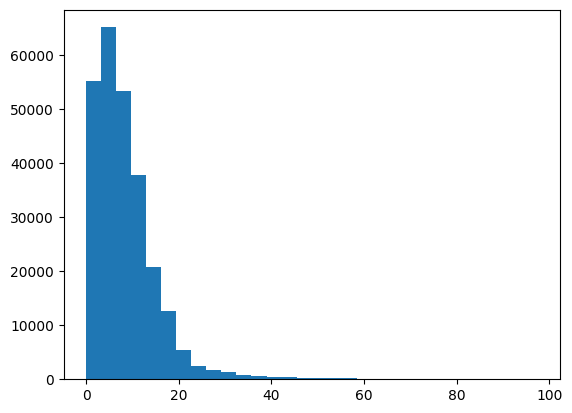

In [67]:
import matplotlib.pyplot as plt
plt.hist(df['Energy (kWh)'], bins=30)
plt.show()

In [68]:
df_grouped = df.groupby(['Station Name', 'Hour'])['Energy (kWh)'].sum().reset_index()

In [69]:
print("Stations:", df['Station Name'].nunique())
print("Hours:", df['Hour'].nunique())
print("Weekdays:", df['Weekday'].nunique())

Stations: 47
Hours: 24
Weekdays: 7


In [70]:
df['City'].value_counts(normalize=True)

City
Palo Alto    1.0
Name: proportion, dtype: float64

### The dataset shows good spatial and temporal diversity with 47 stations, full 24-hour coverage, and all weekdays represented. While the energy consumption distribution is right-skewed, this reflects natural EV charging behavior rather than structural bias.

# **Data Cleaning**


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259415 entries, 0 to 259414
Data columns (total 35 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   Station Name                     259415 non-null  object        
 1   MAC Address                      259415 non-null  object        
 2   Org Name                         259415 non-null  object        
 3   Start Date                       259415 non-null  datetime64[ns]
 4   Start Time Zone                  259415 non-null  object        
 5   End Date                         259415 non-null  object        
 6   End Time Zone                    259415 non-null  object        
 7   Transaction Date (Pacific Time)  259206 non-null  object        
 8   Total Duration (hh:mm:ss)        259415 non-null  object        
 9   Charging Time (hh:mm:ss)         259415 non-null  object        
 10  Energy (kWh)                     259415 non-

In [72]:
df.shape

(259415, 35)

In [73]:
##these are unnecessary columns

df = df.drop(columns=[
    'MAC Address',
    'User ID',
    'Plug In Event Id',
    'Driver Postal Code',
    'System S/N',
    'Model Number',
    'Start Time Zone',
    'End Time Zone',
    'Transaction Date (Pacific Time)',
    'Address 1',
    'Postal Code',
    'Currency'
])

In [74]:
##these columns have the too many missing values

df = df.drop(columns=['EVSE ID', 'County'])

In [75]:
##removing non-zero energy sessions

df = df[df['Energy (kWh)'] > 0] #non-zero doesn't represent demand

In [76]:
df['Charging Time (hh:mm:ss)'] = pd.to_timedelta(df['Charging Time (hh:mm:ss)'])
df['Charging_Time_Minutes'] = df['Charging Time (hh:mm:ss)'].dt.total_seconds() / 60

df['Total Duration (hh:mm:ss)'] = pd.to_timedelta(df['Total Duration (hh:mm:ss)'])
df['Total_Duration_Minutes'] = df['Total Duration (hh:mm:ss)'].dt.total_seconds() / 60

In [77]:
df = df[[
    'Station Name',
    'City',
    'State/Province',
    'Country',
    'Latitude',
    'Longitude',
    'Port Type',
    'Plug Type',
    'Fee',
    'Energy (kWh)',
    'Charging_Time_Minutes',
    'Total_Duration_Minutes',
    'Hour',
    'Weekday'
]]

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 259415 entries, 0 to 259414
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Station Name            259415 non-null  object 
 1   City                    259415 non-null  object 
 2   State/Province          259415 non-null  object 
 3   Country                 259415 non-null  object 
 4   Latitude                259415 non-null  float64
 5   Longitude               259415 non-null  float64
 6   Port Type               259406 non-null  object 
 7   Plug Type               259415 non-null  object 
 8   Fee                     259415 non-null  float64
 9   Energy (kWh)            259415 non-null  float64
 10  Charging_Time_Minutes   259415 non-null  float64
 11  Total_Duration_Minutes  259415 non-null  float64
 12  Hour                    259415 non-null  int32  
 13  Weekday                 259415 non-null  int32  
dtypes: float64(6), int32

In [79]:
df.shape

(259415, 14)

In [80]:
df_grouped = df.groupby(['Station Name', 'Hour', 'Weekday'])['Energy (kWh)'].sum().reset_index()

In [81]:
df.shape

(259415, 14)

In [82]:
df.isnull().sum().sum()

np.int64(9)

In [83]:
df.isnull().sum()

Station Name              0
City                      0
State/Province            0
Country                   0
Latitude                  0
Longitude                 0
Port Type                 9
Plug Type                 0
Fee                       0
Energy (kWh)              0
Charging_Time_Minutes     0
Total_Duration_Minutes    0
Hour                      0
Weekday                   0
dtype: int64

In [84]:
df['Port Type'] = df['Port Type'].fillna(df['Port Type'].mode()[0])

In [85]:
df.isnull().sum()

Station Name              0
City                      0
State/Province            0
Country                   0
Latitude                  0
Longitude                 0
Port Type                 0
Plug Type                 0
Fee                       0
Energy (kWh)              0
Charging_Time_Minutes     0
Total_Duration_Minutes    0
Hour                      0
Weekday                   0
dtype: int64

In [86]:
df['Port Type'].value_counts()

Port Type
Level 2    254736
Level 1      4679
Name: count, dtype: int64

In [87]:
## we drop this becuase of the imbalance

df = df.drop(columns=['Port Type'])

# **Data Featuring & Pre Processing**

In [88]:
df_grouped.head()

,Station Name,Hour,Weekday,Energy (kWh)
0,PALO ALTO CA / BRYANT # 1,0,2,1.480
1,PALO ALTO CA / BRYANT # 1,0,6,2.830
2,PALO ALTO CA / BRYANT # 1,9,2,42.064
3,PALO ALTO CA / BRYANT # 1,10,2,11.834
4,PALO ALTO CA / BRYANT # 1,11,6,5.355


In [89]:
df_grouped.shape

(4827, 4)

In [90]:
df_grouped['Peak_Hour'] = df_grouped['Hour'].apply(
    lambda x: 1 if (6 <= x <= 10) or (17 <= x <= 21) else 0
)

In [91]:
df_grouped['Is_Weekend'] = df_grouped['Weekday'].apply(
    lambda x: 1 if x >= 5 else 0
)

In [92]:
station_avg = df_grouped.groupby('Station Name')['Energy (kWh)'].mean()
df_grouped['Station_Avg_Load'] = df_grouped['Station Name'].map(station_avg)

In [93]:
df_grouped['Hour_Weekend_Interaction'] = df_grouped['Hour'] * df_grouped['Is_Weekend']

##**Using One-Hot Encoding to encode the Stations**

In [94]:
df_grouped.columns

Index(['Station Name', 'Hour', 'Weekday', 'Energy (kWh)', 'Peak_Hour',
       'Is_Weekend', 'Station_Avg_Load', 'Hour_Weekend_Interaction'],
      dtype='object')

In [95]:
df_grouped = pd.get_dummies(df_grouped, columns=['Station Name'], drop_first=True)

In [96]:
## Defined Feature and Target

X = df_grouped.drop(columns=['Energy (kWh)'])
y = df_grouped['Energy (kWh)']

In [97]:
##Train-Test Spit

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [98]:
# Peak hour indicator
df_grouped['Peak_Hour'] = df_grouped['Hour'].apply(
    lambda x: 1 if (6 <= x <= 10) or (17 <= x <= 21) else 0
)

In [99]:
# Weekend indicator
df_grouped['Is_Weekend'] = df_grouped['Weekday'].apply(
    lambda x: 1 if x >= 5 else 0
)


In [100]:
# Interaction feature
df_grouped['Hour_Weekend_Interaction'] = df_grouped['Hour'] * df_grouped['Is_Weekend']

In [101]:
df_grouped.head()

,Hour,Weekday,Energy (kWh),Peak_Hour,Is_Weekend,Station_Avg_Load,Hour_Weekend_Interaction,Station Name_PALO ALTO CA / BRYANT #1,Station Name_PALO ALTO CA / BRYANT #2,Station Name_PALO ALTO CA / BRYANT #3,...,Station Name_PALO ALTO CA / SHERMAN 7,Station Name_PALO ALTO CA / SHERMAN 8,Station Name_PALO ALTO CA / SHERMAN 9,Station Name_PALO ALTO CA / TED THOMPSON #1,Station Name_PALO ALTO CA / TED THOMPSON #2,Station Name_PALO ALTO CA / TED THOMPSON #3,Station Name_PALO ALTO CA / TED THOMPSON #4,Station Name_PALO ALTO CA / WEBSTER #1,Station Name_PALO ALTO CA / WEBSTER #2,Station Name_PALO ALTO CA / WEBSTER #3
0,0,2,1.480,0,0,10.025636,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,6,2.830,0,1,10.025636,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,9,2,42.064,1,0,10.025636,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,10,2,11.834,1,0,10.025636,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,11,6,5.355,0,1,10.025636,11,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## **Training & Evaluating Model**

### **Linear Regression**

In [102]:
scaler = StandardScaler()

In [103]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [104]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [105]:
lr_pred = lr.predict(X_test)

In [106]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"Model: {name}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

In [107]:
evaluate_model("Linear Regression", y_test, lr_pred)

Model: Linear Regression
MAE  : 268.0495
MSE  : 118300.7149
RMSE : 343.9487
R2   : 0.3828


### **Tree Based Regression**

In [108]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [109]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [110]:
rf_pred = rf.predict(X_test)

In [111]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

In [112]:
gb.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [113]:
gb_pred = gb.predict(X_test)

In [114]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2:", r2_score(y_test, y_pred))

In [115]:
evaluate_model("Random Forest", y_test, rf_pred)



Random Forest
MAE: 80.0053739811284
RMSE: 118.18742372348669
R2: 0.92712667909191


In [116]:
evaluate_model("Gradient Boosting", y_test, gb_pred)


Gradient Boosting
MAE: 103.59622393580794
RMSE: 154.43181666333078
R2: 0.875577308989157
